In [1]:
!pip install networkx
!pip install scipy

In [2]:
import networkx as nx
import matplotlib.pyplot as plt



def get_positions(graph):
    def visit(graph, n, xc, yc, offset, positions):
        positions.update({n:(xc, yc)})
        to_be_visited=[]
        if graph.nodes[n]['type']!="RESOURCE":
            to_be_visited=graph.neighbors(n)
        yc_inc=0
        #sorted(to_be_visited,key="type")
        for n1 in to_be_visited:
            if n1 not in positions.keys():
                yc_inc=yc_inc+visit(graph, n1, xc + 1, yc + yc_inc, offset, positions)
        print(f"e: {n}, {yc_inc}")
        return max(1,yc_inc)

    positions={}
    visit(graph,"Tn0",0,0,0,positions)
    print(positions)
    return positions

def get_color_map(graph):
    color_map = []
    for id,params in graph.nodes.items():
        type=params.get("type",None)
        if type is None:
            color_map.append('red')
        elif type == "NETWORK":
            color_map.append("blue")#('#0000FF')
        elif type=="STORAGE":
            color_map.append('yellow')
        elif type=="COMPUTE":
            color_map.append('green')
        elif type=="PLACE":
            color_map.append('gray')
        else:
            color_map.append('purple')
    return color_map

In [3]:
flow_file="../data/BeltWasteRecyclingVTest/Flow2.json"
allocation_file="../data/BeltWasteRecyclingVTest/Allocation2.csv"

{'source': 'Tn0', 'dest': 'Tc1', 'probability': 1.0} found
{'source': 'Tc1', 'dest': 'Tn1', 'probability': 1.0} found
{'source': 'Tc1', 'dest': 'Tn5', 'probability': 1.0} found
{'source': 'Tn1', 'dest': 'Tc2', 'probability': 1.0} found
{'source': 'Tc2', 'dest': 'Tn2', 'probability': 1.0} found
{'source': 'Tn2', 'dest': 'Tc3', 'probability': 1.0} found
{'source': 'Tc3', 'dest': 'Tn3', 'probability': 1.0} found
{'source': 'Tc3', 'dest': 'Tn6', 'probability': 1.0} found
{'source': 'Tn3', 'dest': 'Tc4', 'probability': 1.0} found
{'source': 'Tc4', 'dest': 'Tn4', 'probability': 1.0} found
{'source': 'Tc4', 'dest': 'Tn7', 'probability': 1.0} found
{'source': 'Tn4', 'dest': 'Tc5', 'probability': 1.0} found
{'source': 'Tc5', 'dest': 'Tn8', 'probability': 1.0} found
{'source': 'Tn5', 'dest': 'Ts1', 'probability': 1.0} found
{'source': 'Tn6', 'dest': 'Ts2', 'probability': 1.0} found
{'source': 'Tn7', 'dest': 'Ts3', 'probability': 1.0} found
{'source': 'Ts1', 'dest': 'Tn8', 'probability': 1.0} fou

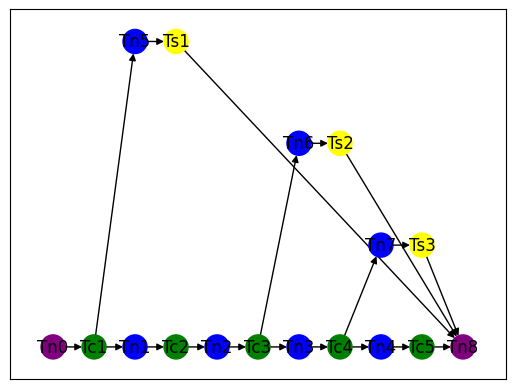

In [4]:
import json
my_flow=json.load(open(flow_file))

G = nx.DiGraph()
nodes={}

for node in my_flow["nodes"]:
#     G.add_nodes_from(node)
    nodes[node["nameTask"]] = node

G.add_nodes_from([(id,params) for id,params in nodes.items()])

#print(G.nodes.items())
for connection in my_flow["connections"]:
    source=connection["source"]
    dest=connection["dest"]
    print(f"{connection} found")
    #if nodes.get(source,None) is not None and nodes.get(dest,None)  is not None:
    #    print(connection)
    G.add_edge(connection["source"],connection["dest"])

#pos = nx.planar_layout(G)
nx.draw_networkx(G,node_color=get_color_map(G),pos=get_positions(G))
#nx.draw(G, node_color=color_map)
plt.show()



DiGraph with 36 nodes and 38 edges
Tn0   {'name': 'Source', 'nameTask': 'Tn0', 'type': 'BEGIN', 'start': 'Tn0_p', 'service': '', 'flowin': ['single', ''], 'flowout': ['split', 'and'], 'resource': [''], 'x': -650, 'y': 200, 'description': 'Source'}
Tc1   {'name': 'Camera_acquisition', 'nameTask': 'Tc1', 'type': 'COMPUTE', 'service': 'Cyber physical interface', 'flowin': ['single', ''], 'flowout': ['split', 'and'], 'resource': ['Tc1_r'], 'x': -450, 'y': 200, 'description': 'Camera_acquisition'}
Tn1   {'name': 'Tn1_t', 'nameTask': 'Tn1', 'type': 'NETWORK', 'service': 'Streaming protocol', 'flowin': ['single', ''], 'flowout': ['single', ''], 'resource': ['Tn1_r'], 'x': -250, 'y': 200, 'description': 'Tn1_t'}
Tc2   {'name': 'Image_processing', 'nameTask': 'Tc2', 'type': 'COMPUTE', 'service': 'Object classifier', 'flowin': ['single', ''], 'flowout': ['single', ''], 'resource': ['Tc1_r'], 'x': -50, 'y': 200, 'description': 'Image_processing'}
Tn2   {'name': 'Tn2_t', 'nameTask': 'Tn2', 'type':

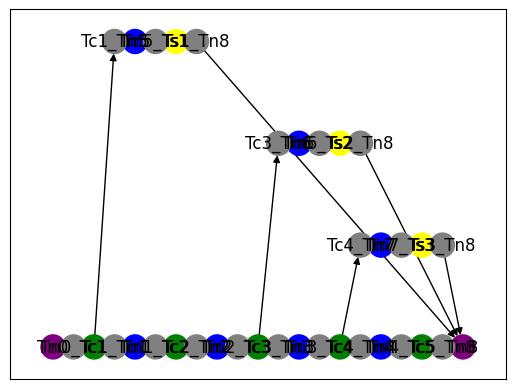

In [5]:
places={}
places_edges=[]
def build_petri_visit(G,n,places,places_edges):
    source_params=G.nodes[n]
    to_be_visited=G.neighbors(n)

    for n1 in to_be_visited:
        dest_params=G.nodes[n1]
        place_name=f"{n}_{n1}"
        places[place_name]={"source":n,"dest":n1,"type":"PLACE"}
        places_edges.append((n,place_name))
        places_edges.append((place_name,n1))
        build_petri_visit(G,n1,places,places_edges)
build_petri_visit(G,"Tn0",places,places_edges)
G2=nx.DiGraph()
G2.add_nodes_from([(id,params) for id,params in nodes.items()])
G2.add_nodes_from([(id,params) for id,params in places.items()])
G2.add_edges_from(places_edges)
print(G2)
for n in G2.nodes:
    print(n," ",str(G2.nodes[n]))

#pos = nx.planar_layout(G)
nx.draw_networkx(G2,node_color=get_color_map(G2),pos=get_positions(G2))
#nx.draw(G, node_color=color_map)
plt.show()



['2', 'Tc1', 'Tc2', 'Tn1', 'Tn2', 'Tn5']
['3', 'Tc3', 'Tc4', 'Tn3', 'Tn4', 'Tn6', 'Tn7']
['4', 'Tc5']
['5', 'Ts1', 'Ts2', 'Ts3']
e: Tn8, 0
e: Tc5_Tn8, 1
e: r4, 0
e: Tc5, 2
e: Tn4_Tc5, 2
e: r3, 0
e: Tn4, 3
e: Tc4_Tn4, 3
e: Ts3_Tn8, 0
e: r5, 0
e: Ts3, 2
e: Tn7_Ts3, 2
e: Tn7, 2
e: Tc4_Tn7, 2
e: Tc4, 5
e: Tn3_Tc4, 5
e: Tn3, 5
e: Tc3_Tn3, 5
e: Ts2_Tn8, 0
e: Ts2, 1
e: Tn6_Ts2, 1
e: Tn6, 1
e: Tc3_Tn6, 1
e: Tc3, 6
e: Tn2_Tc3, 6
e: r2, 0
e: Tn2, 7
e: Tc2_Tn2, 7
e: Tc2, 7
e: Tn1_Tc2, 7
e: Tn1, 7
e: Tc1_Tn1, 7
e: Ts1_Tn8, 0
e: Ts1, 1
e: Tn5_Ts1, 1
e: Tn5, 1
e: Tc1_Tn5, 1
e: Tc1, 8
e: Tn0_Tc1, 8
e: Tn0, 8
{'Tn0': (0, 0), 'Tn0_Tc1': (1, 0), 'Tc1': (2, 0), 'Tc1_Tn1': (3, 0), 'Tn1': (4, 0), 'Tn1_Tc2': (5, 0), 'Tc2': (6, 0), 'Tc2_Tn2': (7, 0), 'Tn2': (8, 0), 'Tn2_Tc3': (9, 0), 'Tc3': (10, 0), 'Tc3_Tn3': (11, 0), 'Tn3': (12, 0), 'Tn3_Tc4': (13, 0), 'Tc4': (14, 0), 'Tc4_Tn4': (15, 0), 'Tn4': (16, 0), 'Tn4_Tc5': (17, 0), 'Tc5': (18, 0), 'Tc5_Tn8': (19, 0), 'Tn8': (20, 0), 'r4': (19, 1), 'r3': (17, 2), 'T

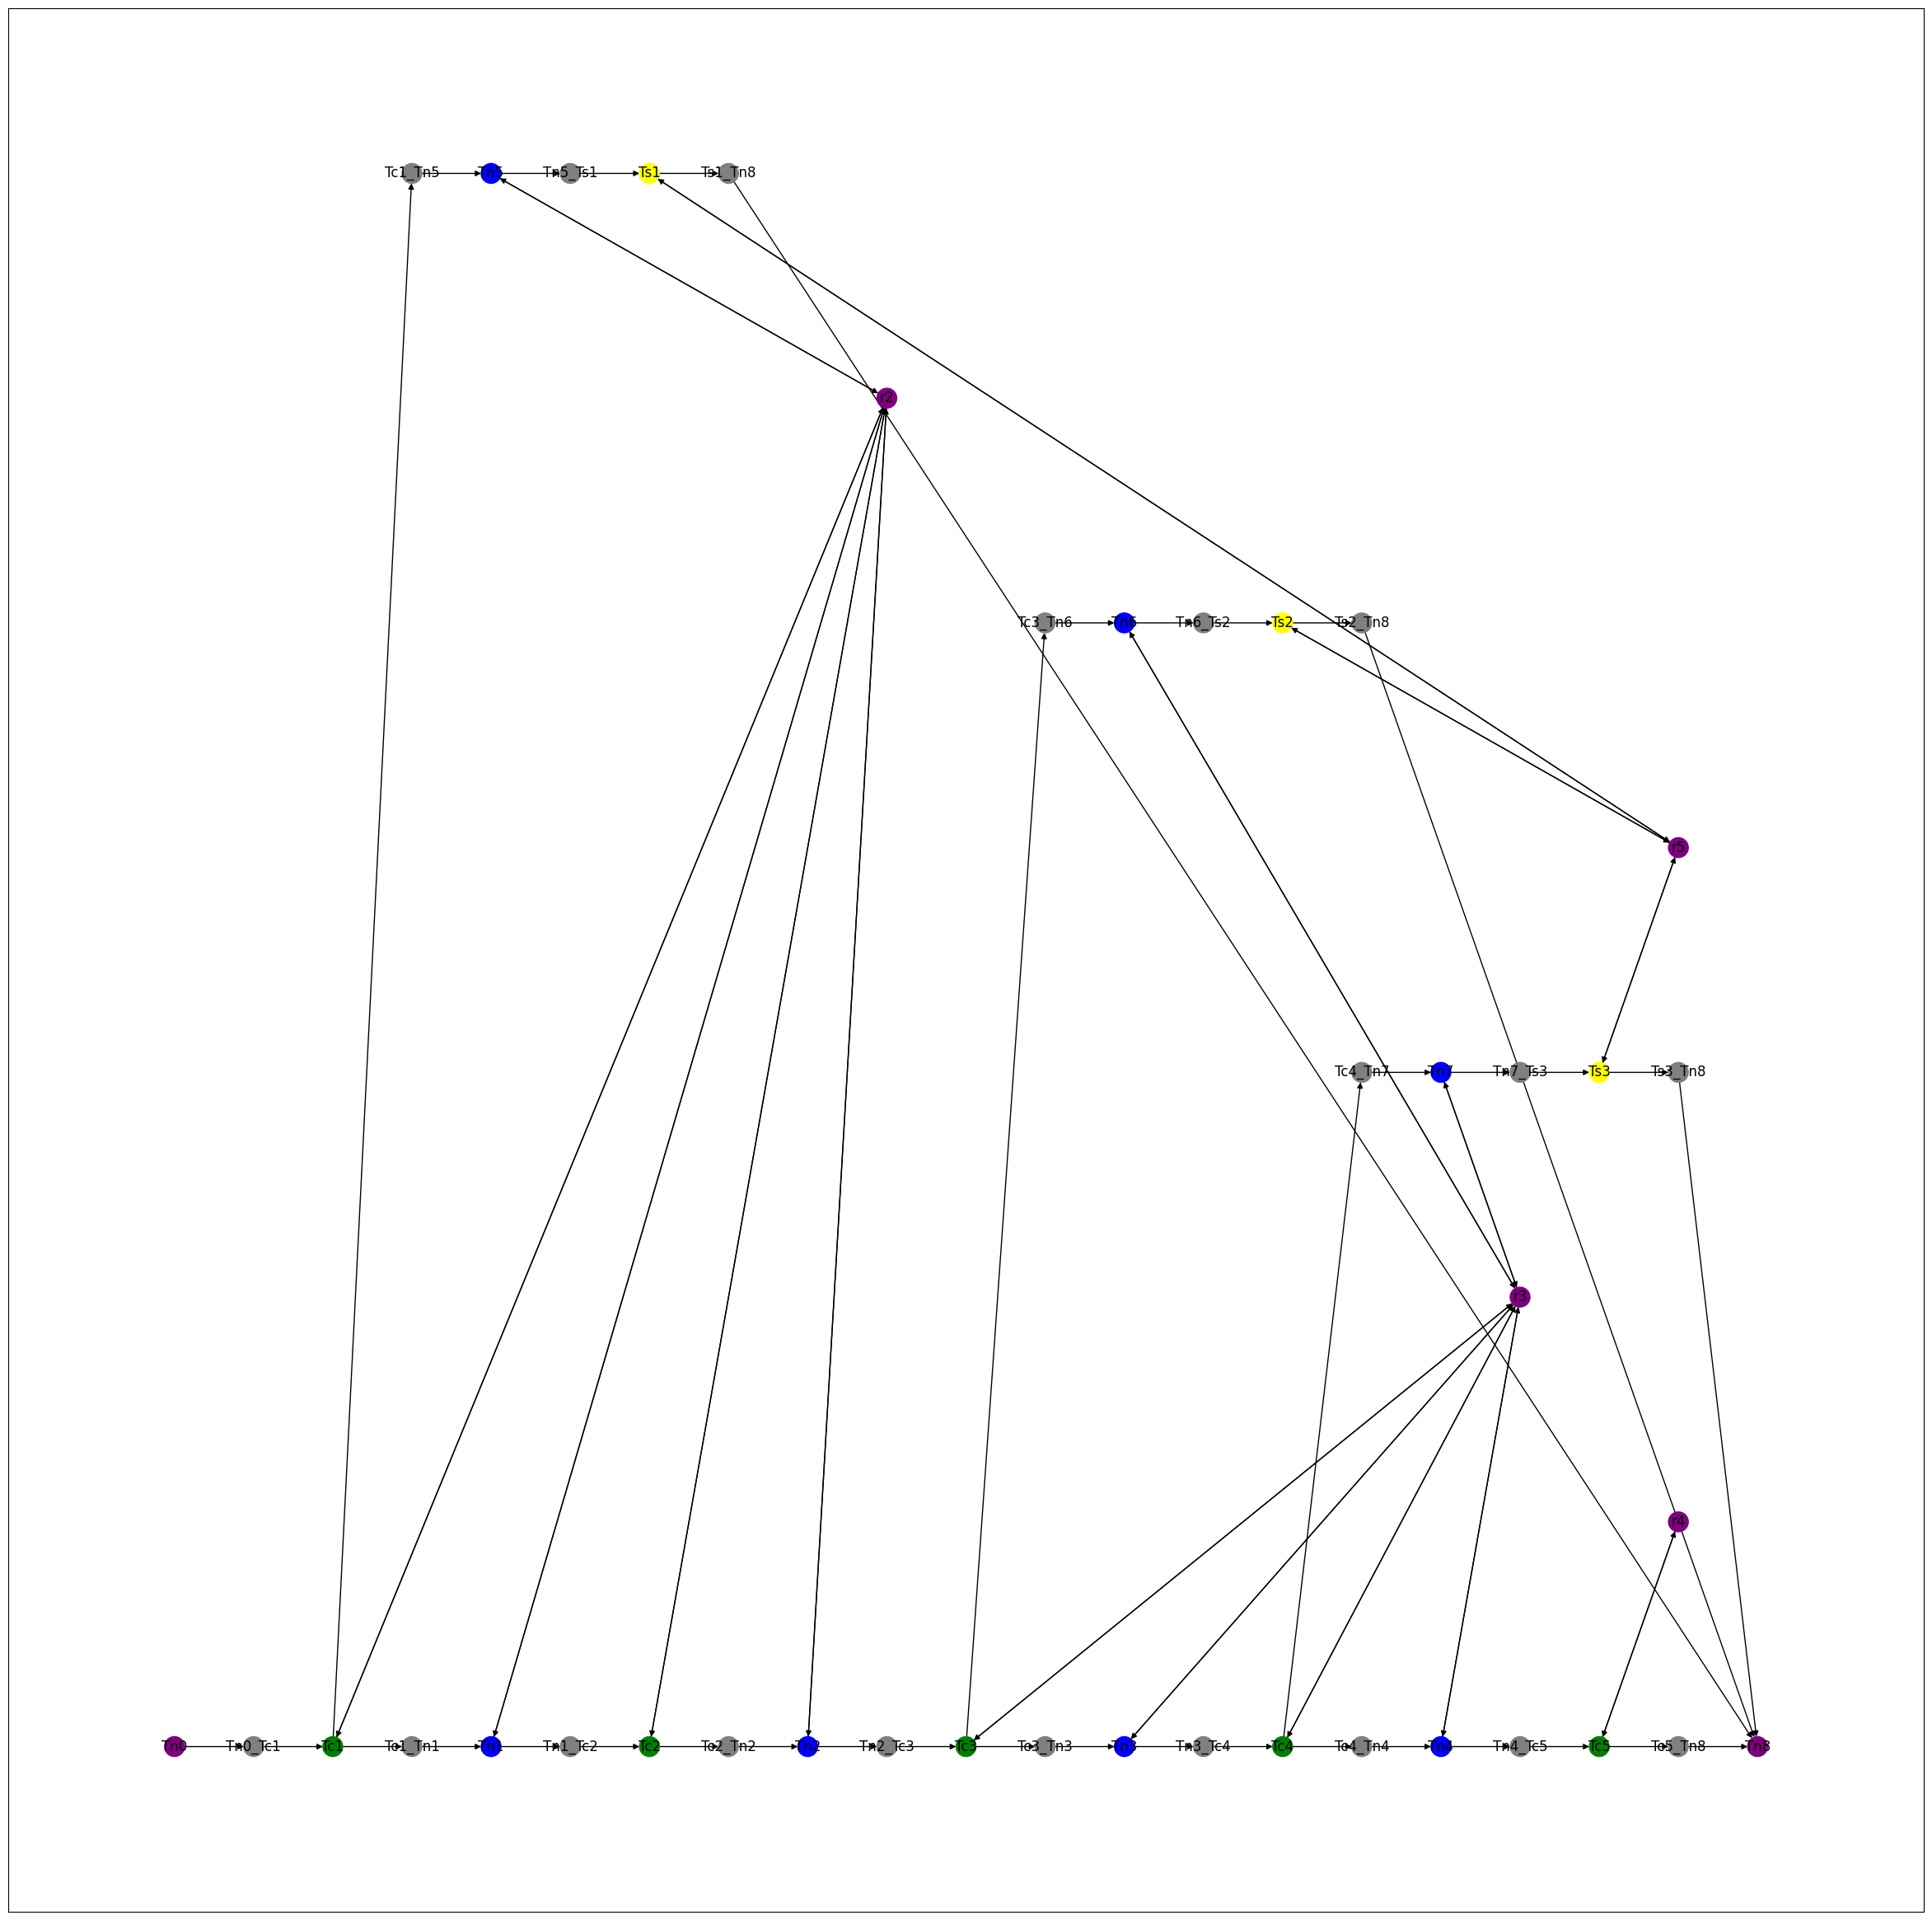

In [6]:
import csv
reader=csv.reader(open(allocation_file))
resource_places={}
resource_edges=[]
for row in reader:
    resource_name=f"r{row[0]}"
    resource_places[resource_name]={"type":"RESOURCE"}
    for a in row[1:]:
        resource_edges.append((resource_name,a))
        resource_edges.append((a,resource_name))
    print(row)

G2.add_nodes_from([(id,params) for id,params in resource_places.items()])
G2.add_edges_from(resource_edges)

import matplotlib.pyplot as plt
plt.figure(1,figsize=(30,30))
nx.draw_networkx(G2,node_color=get_color_map(G2),pos=get_positions(G2))
#nx.draw(G, node_color=color_map)
plt.show()

#print(allocation)

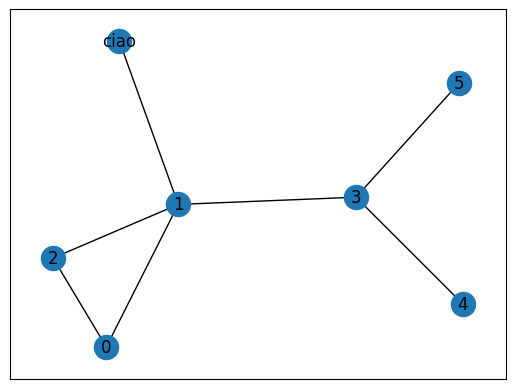

In [60]:
# First networkx library is imported
# along with matplotlib



# Defining a Class
class GraphVisualization:

    def __init__(self):

        # visual is a list which stores all
        # the set of edges that constitutes a
        # graph
        self.visual = []

    # addEdge function inputs the vertices of an
    # edge and appends it to the visual list
    def addEdge(self, a, b):
        temp = [a, b]
        self.visual.append(temp)

    # In visualize function G is an object of
    # class Graph given by networkx G.add_edges_from(visual)
    # creates a graph with a given list
    # nx.draw_networkx(G) - plots the graph
    # plt.show() - displays the graph
    def visualize(self):
        G = nx.Graph()
        G.add_edges_from(self.visual)
        nx.draw_networkx(G)
        plt.show()

# Driver code
G = GraphVisualization()
G.addEdge(0, 2)
G.addEdge(1, 2)
G.addEdge(1, 3)
G.addEdge(5, 3)
G.addEdge(3, 4)
G.addEdge(1, 0)
G.addEdge(1, "ciao")
G.visualize()

In [46]:


positions=get_positions(G2)
print(positions)

#pos = nx.planar_layout(G)
nx.draw_networkx(G2,node_color=color_map,pos=positions)
#nx.draw(G, node_color=color_map)
plt.show()

[('Tn0_Tc1', {'source': 'Tn0', 'dest': 'Tc1', 'type': 'PLACE'})]
a: Tn0_Tc1, 0
[('Tc1', {'name': 'Camera_acquisition', 'nameTask': 'Tc1', 'type': 'COMPUTE', 'service': 'Cyber physical interface', 'flowin': ['single', ''], 'flowout': ['split', 'and'], 'resource': ['Tc1_r'], 'x': -450, 'y': 200, 'description': 'Camera_acquisition'})]
a: Tc1, 0
[('Tc1_Tn1', {'source': 'Tc1', 'dest': 'Tn1', 'type': 'PLACE'}), ('Tc1_Tn5', {'source': 'Tc1', 'dest': 'Tn5', 'type': 'PLACE'}), ('r2', {'type': 'RESOURCE'})]
a: Tc1_Tn1, 0
[('Tn1', {'name': 'Tn1_t', 'nameTask': 'Tn1', 'type': 'NETWORK', 'service': 'Streaming protocol', 'flowin': ['single', ''], 'flowout': ['single', ''], 'resource': ['Tn1_r'], 'x': -250, 'y': 200, 'description': 'Tn1_t'})]
a: Tn1, 0
[('Tn1_Tc2', {'source': 'Tn1', 'dest': 'Tc2', 'type': 'PLACE'}), ('r2', {'type': 'RESOURCE'})]
a: Tn1_Tc2, 0
[('Tc2', {'name': 'Image_processing', 'nameTask': 'Tc2', 'type': 'COMPUTE', 'service': 'Object classifier', 'flowin': ['single', ''], 'flowout'

NameError: name 'color_map' is not defined

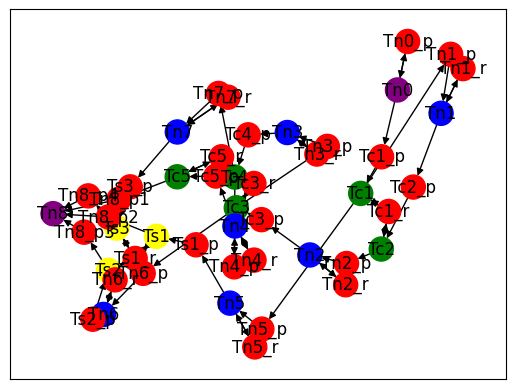

{'Tn0': array([-0.84494471, -0.42668404]), 'Tc1': array([-0.52574378, -0.39409292]), 'Tn1': array([-0.79143709, -0.57969824]), 'Tc2': array([-0.48163091, -0.63352849]), 'Tn2': array([-0.32880051, -0.39933725]), 'Tc3': array([-0.14969405, -0.06227837]), 'Tn3': array([-0.04775058, -0.21373953]), 'Tc4': array([0.17189616, 0.16086373]), 'Tn4': array([0.11191693, 0.60326536]), 'Tc5': array([0.40522499, 0.42830945]), 'Tn5': array([ 0.02838326, -0.11568019]), 'Ts1': array([0.41244751, 0.21748126]), 'Tn6': array([0.06260122, 0.38325566]), 'Ts2': array([0.48302964, 0.42878608]), 'Tn7': array([0.69878108, 0.05822193]), 'Ts3': array([0.50909893, 0.25254416]), 'Tn8': array([0.71955747, 0.56742271]), 'Tn0_p': array([-1.        , -0.51852005]), 'Tc1_p': array([-0.64832234, -0.36656339]), 'Tc1_r': array([-0.5480336 , -0.53739086]), 'Tn1_p': array([-0.92116339, -0.48113642]), 'Tn5_p': array([-0.11574177, -0.2634856 ]), 'Tn1_r': array([-0.93358901, -0.54989728]), 'Tc2_p': array([-0.61220844, -0.6899787

In [22]:
#pos = nx.bfs_layout(G,"Tn0")
#pos = nx.arf_layout(G)
#pos = nx.circular_layout(G)
#pos = nx.forceatlas2_layout(G)
#pos = nx.kamada_kawai_layout(G)
#pos = nx.planar_layout(G)
pos = nx.spring_layout(G)
nx.draw_networkx(G,node_color=color_map)
#nx.draw(G, node_color=color_map)
plt.show()
print(pos)